
**License & Credits**

MIT License © 2025 ryuau0324


In [67]:
%%bash
nvcc --version
nvidia-smi

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2023 NVIDIA Corporation
Built on Fri_Jan__6_16:45:21_PST_2023
Cuda compilation tools, release 12.0, V12.0.140
Build cuda_12.0.r12.0/compiler.32267302_0
Thu Oct 23 11:39:53 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.86.09              Driver Version: 571.96         CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050 ...    On  |   00000000:01:00.0 Off |                  N/A |
| N/A   50C    P0      

In [ ]:
import rdkit
import rdkit.Chem as Chem
import numpy as np
import rdkit.Chem.AllChem as AllChem
import torch
import torch_geometric
from torch_geometric.data import Data
from rdkit.Chem import rdchem
import pandas as pd
import joblib
import numpy as np
import pandas as pd
from pathlib import Path


In [ ]:

OUT = Path(r"C:\Users\Choi u ra\Desktop\laidd_aws\cache_m235")
OUT.mkdir(parents=True, exist_ok=True)

SEED = 42
csv_path = r"C:\Users\Choi u ra\Desktop\laidd_aws\merged_235.csv" 

df = pd.read_csv(csv_path)

# 컬럼 체크
required_cols = {"Catalog_ID", "SMILES", "CNNAffinity"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"CSV에 필요한 컬럼이 없습니다: {missing}")

# 필요한 컬럼만 사용
df = df[["Catalog_ID", "SMILES", "CNNAffinity"]].copy()


# 필요한 컬럼만, NaN 제거
before = len(df)
df = df[["SMILES", "CNNAffinity"]].dropna(subset=["SMILES", "CNNAffinity"])
after = len(df)
if before != after:
    print(f"[INFO] NaN 제거: {before} -> {after}")

# X/Y 배열화
X = df["SMILES"].astype(str).values          # 문자열
Y = df["CNNAffinity"].astype(np.float32).values  # float32

# npy 저장
np.save(OUT / "smiles_all.npy", X, allow_pickle=True)
np.save(OUT / "ca_all.npy", Y)
print(f"[SAVED] X -> {OUT/'smiles_all.npy'} len={len(X)}")
print(f"[SAVED] Y -> {OUT/'ca_all.npy'} len={len(Y)}")

tr_path, va_path, te_path = OUT/"idx_train.npy", OUT/"idx_val.npy", OUT/"idx_test.npy"
for p in [tr_path, va_path, te_path]:
    if not p.exists():
        raise FileNotFoundError(f"필수 인덱스 파일이 없습니다: {p}")

tr = np.load(tr_path)
va = np.load(va_path)
te = np.load(te_path)

#  인덱스 유효성 검증 
n = len(X)

def check_indices(name, idx, n):
    idx = np.asarray(idx)
    if idx.ndim != 1:
        raise ValueError(f"{name} 인덱스가 1차원이 아닙니다 (shape={idx.shape}).")
    if len(idx) == 0:
        raise ValueError(f"{name} 인덱스가 비어 있습니다.")
    if idx.min() < 0 or idx.max() >= n:
        raise IndexError(f"{name} 인덱스가 범위를 벗어났습니다: min={idx.min()}, max={idx.max()}, n={n}")
    if len(np.unique(idx)) != len(idx):
        dup = len(idx) - len(np.unique(idx))
        raise ValueError(f"{name} 인덱스에 중복이 있습니다: {dup}개")

check_indices("train", tr, n)
check_indices("val", va, n)
check_indices("test", te, n)

# 분할 간 중복 여부 체크
overlap = (
    len(np.intersect1d(tr, va)) +
    len(np.intersect1d(tr, te)) +
    len(np.intersect1d(va, te))
)
if overlap > 0:
    raise ValueError(f"train/val/test 분할 간 중복 인덱스가 있습니다 (총 {overlap}개).")

print("[OK] 기존 인덱스 사용: "
      f"train={len(tr)}, val={len(va)}, test={len(te)} / 전체={n}")

# 매칭 검증
def summary(name, idx, Y):
    y = Y[idx]
    print(f"{name:>5}: n={len(idx)}, mean={float(np.mean(y)):.4f}, std={float(np.std(y)):.4f}, "
          f"min={float(np.min(y)):.4f}, max={float(np.max(y)):.4f}")

summary("ALL", np.arange(n), Y)
summary("TR", tr, Y)
summary("VA", va, Y)
summary("TE", te, Y)


[SAVED] X -> C:\Users\Choi u ra\Desktop\laidd_aws\cache_m235\smiles_all.npy len=60159
[SAVED] Y -> C:\Users\Choi u ra\Desktop\laidd_aws\cache_m235\ca_all.npy len=60159
[OK] 기존 인덱스 사용: train=42111, val=12032, test=6016 / 전체=60159
  ALL: n=60159, mean=6.4319, std=0.5839, min=3.0124, max=8.6293
   TR: n=42111, mean=6.4313, std=0.5823, min=3.0124, max=8.6293
   VA: n=12032, mean=6.4327, std=0.5892, min=3.0448, max=8.4172
   TE: n=6016, mean=6.4347, std=0.5840, min=3.4307, max=8.3306


In [ ]:

#convert_pdbqt_to_graph

import math
import torch

# 
def _dist(ax, ay, az, bx, by, bz):
    dx, dy, dz = ax - bx, ay - by, az - bz
    return (dx*dx + dy*dy + dz*dz) ** 0.5

def rbf(d, centers=(1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6), gamma=8.0):
    """Radial Basis encoding for distances"""
    return [math.exp(-gamma * (d - c) ** 2) for c in centers]

#  AD-type → element 
def _adtype_from_line(line: str) -> str:
    """우선 마지막 토큰, 없으면 고정폭 [77:79]에서 AD 타입 추출"""
    parts = line.split()
    atype = parts[-1].upper() if parts else ""
    if not atype and len(line) >= 79:
        atype = line[77:79].strip().upper()
    return atype

def _elem_from_adtype_or_name(atype: str, name_field: str) -> str | None:
    """AD 타입 기준으로 원소 추정"""
    a = (atype or "").upper()
    # AD 타입 매핑
    if a in ("C", "A"):              return "C"     # 'A' aromatic carbon
    if a in ("OA",) or a.startswith("O"): return "O"
    if a in ("NA",) or a.startswith("N"): return "N"
    if a in ("HD",) or a.startswith("H"): return "H"
    if a.startswith("S"):            return "S"
    if a.startswith("P"):            return "P"
    if a.startswith("F"):            return "F"
    if a.startswith("CL"):           return "Cl"
    if a.startswith("BR"):           return "Br"
    if a.startswith("I"):            return "I"

    # name fallback 
    s = ''.join(ch for ch in name_field if ch.isalpha())
    if len(s) >= 2 and s[1].islower():
        return s[:2].title()
    if len(s) >= 1:
        return s[:1].upper()
    return None

#  simple physicochemical features -
_periodic = {
    "H":  {"EN":2.20, "radius":53,  "val":1},
    "C":  {"EN":2.55, "radius":70,  "val":4},
    "N":  {"EN":3.04, "radius":65,  "val":5},
    "O":  {"EN":3.44, "radius":60,  "val":6},
    "F":  {"EN":3.98, "radius":50,  "val":7},
    "P":  {"EN":2.19, "radius":100, "val":5},
    "S":  {"EN":2.58, "radius":100, "val":6},
    "Cl": {"EN":3.16, "radius":100, "val":7},
    "Br": {"EN":2.96, "radius":115, "val":7},
    "I":  {"EN":2.66, "radius":125, "val":7},
}
def chem_binding_features(elem: str, formal_charge: float = 0.0):
    d = _periodic.get(elem)
    if not d:
        return [0.0, 0.0, 0.0, formal_charge]
    # 간단 정규화
    return [d["EN"]/4.0, d["val"]/8.0, d["radius"]/150.0, formal_charge]

#  parser
def parse_pdbqt_ligand(pdbqt_path: str):
    """
    리간드 PDBQT 파싱 → [(elem, atype, x, y, z, is_aromatic, formal_charge)]
    - AD 타입은 마지막 토큰 우선, 없으면 고정폭 [77:79]
    - 방향족 여부: atype == 'A'
    - formal_charge: 마지막-1 토큰이 숫자면 채택(없으면 0.0)
    """
    atoms = []
    with open(pdbqt_path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            if not (line.startswith("ATOM") or line.startswith("HETATM")):
                continue

            name = line[12:16].strip()
            x = float(line[30:38]); y = float(line[38:46]); z = float(line[46:54])

            atype = _adtype_from_line(line)
            elem = _elem_from_adtype_or_name(atype, name)
            if elem in {"H","G"}:
                continue

            # partial charge(마지막-1 토큰 시도)
            parts = line.split()
            q = 0.0
            if len(parts) >= 2:
                try:
                    q = float(parts[-2])
                except:
                    q = 0.0

            is_aromatic = int((atype or "").upper() == "A")
            atoms.append((elem, (atype or "").upper(), x, y, z, is_aromatic, q))
    return atoms

# convert to graph 
def convert_pdbqt_to_graph(pdbqt_path: str, cutoff: float = 1.85, keep_h: bool = False):
    """
    PDBQT → (edge_index, x, edge_attr, pos, edge_weight)
      - keep_h=False: H 노드 제외(heavy-only)  
      - 노드 피처: element one-hot + AD-type one-hot + aromatic flag + (EN,val,radius,charge)
      - 엣지: 거리 기반(양방향) + [dist + RBF]
    """
    atoms = parse_pdbqt_ligand(pdbqt_path)
    if not atoms:
        return None

    # 노드 사전 (heavy-only 기본)
    HEAVY = ["C","N","O","S","P","F","Cl","Br","I"]
    ELEMENTS = (["H"] + HEAVY) if keep_h else HEAVY

    # AD-type 카테고리
    ADTYPES = ["A","C","C.3","C.2","C.ar","N","NA","N.am","N.pl3","O","OA","O.3","S","P","F","CL","BR","I","HD","H"]

    feats, coords = [], []
    for elem, atype, x, y, z, is_arom, q in atoms:
        if elem not in ELEMENTS:
            continue
        e_one = [int(elem == e) for e in ELEMENTS]
        t_one = [int(atype == t) for t in ADTYPES]
        bind  = chem_binding_features(elem, q)
        feats.append(e_one + t_one + [is_arom] + bind)
        coords.append([x, y, z])

    if not coords:
        return None  # heavy-only로 남는 노드가 없을 때

    x   = torch.tensor(feats,  dtype=torch.float)
    pos = torch.tensor(coords, dtype=torch.float)

    # 거리 기반 엣지(+대칭)
    N = len(coords)
    ei, ea, ew = [], [], []
    rbf_len = len(rbf(0.0))
    for i in range(N):
        xi, yi, zi = coords[i]
        for j in range(i+1, N):
            xj, yj, zj = coords[j]
            d = _dist(xi, yi, zi, xj, yj, zj)
            if d <= cutoff:
                f = [d] + rbf(d)
                ei.append([i, j]); ei.append([j, i])
                ea.append(f);     ea.append(f)
                ew.append(d);     ew.append(d)

    edge_index = torch.tensor(ei, dtype=torch.long).t().contiguous() if ei else torch.empty((2,0), dtype=torch.long)
    edge_attr  = torch.tensor(ea, dtype=torch.float) if ea else torch.empty((0, 1+rbf_len), dtype=torch.float)
    edge_weight= torch.tensor(ew, dtype=torch.float) if ew else torch.empty((0,), dtype=torch.float)
    return edge_index, x, edge_attr, pos, edge_weight


In [ ]:
edge_index, node_attr, edge_attr, pos, edge_weight = convert_pdbqt_to_graph(
    r"C:\Users\Choi u ra\Desktop\laidd_aws\aligned_pdbqt\Z1995549361.pdbqt"
)

print("node_attr:", node_attr.shape)
print("edge_index:", edge_index.shape)
print("edge_attr:", edge_attr.shape)
print("pos:", pos.shape)


node_attr: torch.Size([21, 34])
edge_index: torch.Size([2, 46])
edge_attr: torch.Size([46, 8])
pos: torch.Size([21, 3])


node_attr[21,34]
element one-hot	C, N, O, S, P, Cl, Br, I 등 9종	9차원
AD-type one-hot	C, N, O, NA, OA, A …	약 20차원
aromatic flag	방향족 여부	1차원
화학적 scalar	전기음성도, 원자가, 원자 반지름, 전하	4차원
합계	9 + 20 + 1 + 4	≈34차원
edge_index: [2, 46] 총 46개의 방향성 엣지(즉, i→j)가
edge_attr: [46, 8]
distance	두 원자 사이 거리 (Å)	1
RBF(거리 인코딩)	여러 중심(1.4, 1.6, 1.8, …)에서의 가우시안	7
pos: [21, 3]
각 원자의 3D 좌표(x, y, z).
21개의 원자- 21×3 좌표 행렬

In [ ]:
edge_index, x, edge_attr, pos, edge_weight = convert_pdbqt_to_graph(objective[0][0])

In [ ]:
d0 = Data(x = x, edge_index = edge_index, edge_attr = edge_attr, pos = pos, edge_weight = edge_weight)

In [ ]:
print(d0)

Data(x=[30, 34], edge_index=[2, 64], edge_attr=[64, 8], pos=[30, 3], edge_weight=[64])


x=[30,34]	30개의 원자, 각 34차원 피처	탄화수소 계열일 가능성
edge_index=[2,64]	32쌍의 결합	30개 원자 간 공유결합
edge_attr=[64,8]	거리 + RBF 인코딩	결합 거리 분포 반영
pos=[30,3]	원자 좌표	리간드 3D 구조
edge_weight=[64]	각 엣지의 실제 거리 값	거리 기반 그래프 학습용

In [ ]:
d0.num_nodes #원자개수

30

In [ ]:
import os
import torch
import pandas as pd
from tqdm import tqdm
from torch_geometric.data import Data

CSV_PATH  = r"C:\Users\Choi u ra\Desktop\laidd_aws\merged_235.csv"
PDBQT_DIR = r"C:\Users\Choi u ra\Desktop\docked_pdbqt"
OUT_PATH  = r"C:\Users\Choi u ra\Desktop\laidd_data\pdbqt_mol_dataset2.pt"

merged = pd.read_csv(CSV_PATH)
merged["Catalog_ID"] = merged["Catalog_ID"].astype(str).str.strip()
ids     = merged["Catalog_ID"].values
smiles  = merged["SMILES"].astype(str).values
scores  = merged["CNNAffinity"].astype(float).values

# 그래프 생성 
data_list = []
n_total, n_built, n_none, n_missing = 0, 0, 0, 0

for cid, smi, score in tqdm(zip(ids, smiles, scores), total=len(ids), desc="[Building Ligand Graphs]"):
    pdbqt_path = os.path.join(PDBQT_DIR, f"{cid}.pdbqt")
    n_total += 1

    if not os.path.exists(pdbqt_path):
        n_missing += 1
        continue

    result = convert_pdbqt_to_graph(pdbqt_path)
    if result is None:
        n_none += 1
        continue

    edge_index, x, edge_attr, pos, edge_weight = result
    y = torch.tensor([[float(score)]], dtype=torch.float)

    d = Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        pos=pos,
        edge_weight=edge_weight,
        y=y
    )
    # 메타데이터 추가
    d.cid = cid          # Catalog_ID
    d.smiles = smi       # SMILES
    d.label = float(score)  # CNNAffinity 라벨 값
    data_list.append(d)
    n_built += 1

torch.save(data_list, OUT_PATH)

print(f"\n완성된 리간드 그래프: {n_built} / {n_total}")
print(f" None 스킵: {n_none}, 파일 없음: {n_missing}")
print(f" 저장 경로: {OUT_PATH}")

[Building Ligand Graphs]: 100%|██████████| 60159/60159 [11:56<00:00, 84.00it/s]  



완성된 리간드 그래프: 60159 / 60159
 None 스킵: 0, 파일 없음: 0
 저장 경로: C:\Users\Choi u ra\Desktop\laidd_data\pdbqt_mol_dataset2.pt


In [95]:
lig_list = torch.load(r"C:\Users\Choi u ra\Desktop\laidd_data\pdbqt_mol_dataset2.pt", weights_only=False)

print("총 개수:", len(lig_list))
print("예시 CID:", lig_list[0].cid)
print("예시 SMILES:", lig_list[0].smiles)
print("예시 Label:", lig_list[0].label)

총 개수: 60159
예시 CID: Z15902865
예시 SMILES: CCNC(=O)CSC1=NN=C(C=2C=C(Cl)C=CC2OC)N1C=3C=CC(OC)=C(Cl)C3
예시 Label: 7.38296


In [6]:
import torch

ligand_list = torch.load(r"C:\Users\Choi u ra\Desktop\laidd_data\pdbqt_mol_dataset2.pt", weights_only=False)

print(len(ligand_list))

print(ligand_list[0])


60159
Data(x=[30, 34], edge_index=[2, 64], edge_attr=[64, 8], y=[1, 1], pos=[30, 3], edge_weight=[64], cid='Z15902865', smiles='CCNC(=O)CSC1=NN=C(C=2C=C(Cl)C=CC2OC)N1C=3C=CC(OC)=C(Cl)C3', label=7.38296)


in_channels	입력 피처 차원	: 34 (리간드 원자 피처 크기)

out_channels	각 attention head가 출력할 차원	ex) 32

heads	병렬로 계산할 attention head 개수	ex) 4

concat	여러 head 결과를 “합칠지(concat)” or “평균낼지(mean)”	ex) True면 32×4=128

edge_dim	edge_attr (엣지 피처) 차원	ex) 거리+RBF 8차원

dropout	어텐션 dropout	optional

In [ ]:
import torch
import torch.nn as nn
from torch_geometric.nn import GATv2Conv

class LigandEncoderGNN(nn.Module):
    def __init__(self, in_dim, hidden_dim=128, heads=4, num_layers=3, edge_dim=8, dropout=0.1, return_nodes=True):
        super().__init__()
        self.return_nodes = return_nodes
        self.dropout = dropout
        self.convs, self.norms = nn.ModuleList(), nn.ModuleList()
        # in -> 128 (concat=True, 4 heads => 32*4=128)
        self.convs.append(GATv2Conv(in_dim, hidden_dim // heads, heads=heads, edge_dim=edge_dim, concat=True))
        self.norms.append(nn.LayerNorm(hidden_dim))
        # mid (128 -> 128)
        for _ in range(num_layers - 2):
            self.convs.append(GATv2Conv(hidden_dim, hidden_dim // heads, heads=heads, edge_dim=edge_dim, concat=True))
            self.norms.append(nn.LayerNorm(hidden_dim))
        # last (concat=False => ch=hidden_dim)
        self.convs.append(GATv2Conv(hidden_dim, hidden_dim, heads=4, edge_dim=edge_dim, concat=False))
        self.norms.append(nn.LayerNorm(hidden_dim))
        self.act = nn.ReLU()

    def forward(self, data):
        x, ei, ea = data.x, data.edge_index, data.edge_attr
        for conv, ln in zip(self.convs, self.norms):
            x = self.act(conv(x, ei, ea))
            x = ln(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        return x  # ← 노드 임베딩 [N_lig,128]  


In [ ]:
import torch.nn.functional as F

#리리 임베딩 벡터얻기
from torch_geometric.loader import DataLoader


ligand_list = torch.load(r"C:\Users\Choi u ra\Desktop\laidd_data\pdbqt_mol_dataset2.pt",weights_only=False)
loader = DataLoader(ligand_list, batch_size=64, shuffle=True)

# 모델 초기화
in_dim = ligand_list[0].x.size(1)     # 노드 feature 수
edge_dim = ligand_list[0].edge_attr.size(1)  # 8
model = LigandEncoderGNN(in_dim=in_dim, hidden_dim=128, edge_dim=edge_dim)

# 순전파
for batch in loader:
    emb_ligand = model(batch)  # [batch_size, 128]
    print(emb_ligand.shape)
    break


torch.Size([1518, 128])


In [9]:
#단단 그래프벡터
import torch
from torch_geometric.data import Data
from collections import namedtuple
import math, re

Atom = namedtuple("Atom", ["serial","name","altloc","resname","chain","resseq","icode","x","y","z","occ","b","element"])

AA3 = {"ALA","ARG","ASN","ASP","CYS","GLN","GLU","GLY","HIS","ILE","LEU","LYS","MET","PHE","PRO","SER","THR","TRP","TYR","VAL"}
RES29 = {743,776,841,842,800,855,775,791,762,719,724,796,718,792,844,716,728,745,766,790,793,723,795,856,794,797,854,726,720}
ROLEMAP = {("A",793):1, ("A",790):2, ("A",745):3}  # hinge/gatekeeper/catalytic

def _infer_element_from_name(atom_name: str) -> str:
    s = re.sub(r'[^A-Za-z]', '', atom_name)
    if not s: return ""
    if len(s)>=2 and s[1].islower(): return s[:2].title()
    return s[:1].upper()

def _dist(ax, ay, az, bx, by, bz):
    dx,dy,dz = ax-bx, ay-by, az-bz
    return (dx*dx+dy*dy+dz*dz)**0.5

def parse_pdb(pdb_path):
    atoms = []
    with open(pdb_path,"r",encoding="utf-8",errors="ignore") as f:
        for line in f:
            if not (line.startswith("ATOM") or line.startswith("HETATM")):
                continue
            serial = int(line[6:11])
            name   = line[12:16].strip()
            resname= line[17:20].strip()
            chain  = line[21].strip()
            resseq = int(line[22:26])
            x = float(line[30:38]); y = float(line[38:46]); z = float(line[46:54])
            occ= line[54:60].strip(); occ = float(occ) if occ else 0.0
            b  = line[60:66].strip(); b   = float(b) if b else 0.0
            element = line[76:78].strip() or _infer_element_from_name(name)
            atoms.append(Atom(serial,name,"",resname,chain,resseq,"",x,y,z,occ,b,element))
    return [a for a in atoms if a.resname in AA3]  # 아미노산만 남김

def parse_pdbqt(p):
    lig = []
    with open(p,"r",encoding="utf-8",errors="ignore") as f:
        for line in f:
            if line.startswith("ATOM") or line.startswith("HETATM"):
                x = float(line[30:38]); y=float(line[38:46]); z=float(line[46:54])
                lig.append((x,y,z))
    return lig

def select_pocket_atoms(protein_atoms, ligand_xyz, cutoff=5.0):
    pocket = []
    for pa in protein_atoms:
        for lx,ly,lz in ligand_xyz:
            if _dist(pa.x,pa.y,pa.z, lx,ly,lz) <= cutoff:
                pocket.append(pa)
                break
    return pocket

ELEMENTS = ["H","B","C","N","O","F","P","S","Cl","Br","I","Zn","Mg","Ca","Na","K","Fe","Cu","Ni","Co","Mn"]
RESLIST  = sorted(list(AA3))

def one_hot(val, vocab):
    v = [0]*len(vocab)
    try: v[vocab.index(val)] = 1
    except: pass
    return v

def make_protein_PP(pdb_path, ligand_pdbqt_path, cutoff=5.0, dcut_edge=4.8):
    prot = parse_pdb(pdb_path)
    lig_xyz = parse_pdbqt(ligand_pdbqt_path)
    pocket = select_pocket_atoms(prot, lig_xyz, cutoff=cutoff)

    feats, pos = [], []
    for a in pocket:
        f = []
        f += one_hot(a.element, ELEMENTS)
        f += one_hot(a.resname, RESLIST)
        f += [1 if (a.chain=="A" and a.resseq in RES29) else 0]
        role_id = ROLEMAP.get((a.chain, a.resseq), 0)
        role_one = [int(role_id==k) for k in range(4)]  # [none, hinge, gate, catalytic]
        f += role_one
        feats.append(f)
        pos.append([a.x,a.y,a.z])

    if not feats:
        return None, []

    x = torch.tensor(feats, dtype=torch.float)
    pos = torch.tensor(pos, dtype=torch.float)

    # 거리 기반 edge + edge_attr 추가
    def _rbf(d, centers=(2.0, 2.5, 3.0, 3.5, 4.0, 4.5), gamma=4.0):
        return [math.exp(-gamma * (d - c) ** 2) for c in centers]

    N = pos.size(0)
    ei, ea = [], []
    for i in range(N):
        xi, yi, zi = pos[i].tolist()
        for j in range(i+1, N):
            xj, yj, zj = pos[j].tolist()
            d = _dist(xi,yi,zi, xj,yj,zj)
            if d <= dcut_edge:
                ei.append([i,j]); ei.append([j,i])
                f = [d] + _rbf(d)       # 거리 + RBF 인코딩
                ea.append(f); ea.append(f)

    edge_index = (
        torch.tensor(ei, dtype=torch.long).t().contiguous()
        if ei else torch.empty((2,0),dtype=torch.long)
    )
    edge_attr = (
        torch.tensor(ea, dtype=torch.float)
        if ea else torch.empty((0, 1+len(_rbf(0.0))), dtype=torch.float)
    )

    return Data(x=x, pos=pos, edge_index=edge_index, edge_attr=edge_attr), pocket


In [93]:
from tqdm import tqdm
import torch, os
from torch_geometric.data import Data

protein_graphs = []
pdb_path = r"C:\Users\Choi u ra\Desktop\laidd_aws\8wd4.pdb"
ligand_dir = r"C:\Users\Choi u ra\Desktop\docked_pdbqt"

for cid in tqdm(ids, desc="[Building Protein Graphs]"):
    ligand_path = os.path.join(ligand_dir, f"{cid}.pdbqt")
    if not os.path.exists(ligand_path):
        continue

    result = make_protein_PP(pdb_path, ligand_path)
    if result is None:
        continue

    d, pocket = result


    protein_graphs.append(d)

torch.save(protein_graphs, r"C:\Users\Choi u ra\Desktop\laidd_data\protein_pocket_dataset2.pt")

[Building Protein Graphs]: 100%|██████████| 60159/60159 [52:03<00:00, 19.26it/s]   


In [10]:
import torch
data_list = torch.load(r"C:\Users\Choi u ra\Desktop\laidd_data\protein_pocket_dataset2.pt", weights_only=False)

print(len(data_list))

print(data_list[0])



60159
Data(x=[64, 46], edge_index=[2, 472], edge_attr=[472, 7], pos=[64, 3], cid='Z15902865')


In [ ]:
#단단 엣지 잘만들어지나?
import torch

def edge_distance_stats(data):
    pos = data.pos  # [N,3]
    ei = data.edge_index  # [2,E]
    if ei.numel() == 0:
        return None
    src, dst = ei[0], ei[1]
    d = torch.linalg.vector_norm(pos[src] - pos[dst], dim=1)  # [E]
    return {
        "E": ei.size(1),
        "min": float(d.min()),
        "mean": float(d.mean()),
        "max": float(d.max())
    }


stats = edge_distance_stats(data_list[8])
print(stats)  

{'E': 582, 'min': 1.2241135835647583, 'mean': 3.331582546234131, 'max': 4.795999526977539}


In [ ]:
#리간드별 단백질 차이보이는지?

import os
import random
import pandas as pd
from tqdm import tqdm

merged = pd.read_csv(r"C:\Users\Choi u ra\Desktop\laidd_aws\merged_235.csv")
ids = merged["Catalog_ID"].astype(str).tolist()

#  무작위 10개 리간드 선택
sample_ids = random.sample(ids, 10)

pdb_path = r"C:\Users\Choi u ra\Desktop\laidd_aws\8wd4.pdb"
ligand_dir = r"C:\Users\Choi u ra\Desktop\docked_pdbqt"

print("[CHECK] Random 10 ligand pocket sizes:\n")

for cid in tqdm(sample_ids, desc="[DEBUG] 10 sample ligands"):
    ligand_path = os.path.join(ligand_dir, f"{cid}.pdbqt")
    if not os.path.exists(ligand_path):
        print(f"{cid}: (MISSING)")
        continue

    try:
        result = make_protein_PP(pdb_path, ligand_path)
        if result is None or result[0] is None:
            print(f"{cid}: (EMPTY)")
            continue

        d, pocket = result
        num_nodes = d.x.size(0)
        num_edges = d.edge_index.size(1)

        print(f"{cid}: {num_nodes} pocket atoms, {num_edges} edges")

    except Exception as e:
        print(f"{cid}: ERROR -> {e}")


[CHECK] Random 10 ligand pocket sizes:



[DEBUG] 10 sample ligands:  20%|██        | 2/10 [00:00<00:00, 17.70it/s]

Z1626362136: 84 pocket atoms, 940 edges
Z2391431085: 82 pocket atoms, 928 edges
Z1694821512: 64 pocket atoms, 622 edges
Z1891842389: 73 pocket atoms, 822 edges
Z2053437801: 67 pocket atoms, 660 edges

[DEBUG] 10 sample ligands: 100%|██████████| 10/10 [00:00<00:00, 22.94it/s]


Z85880993: 86 pocket atoms, 986 edges
Z1917775943: 78 pocket atoms, 856 edges
Z2166317786: 67 pocket atoms, 752 edges
Z410226344: 89 pocket atoms, 1064 edges
Z2219332596: 78 pocket atoms, 922 edges


In [ ]:
import torch
from collections import Counter

data_list = torch.load("protein_pocket_dataset2.pt", weights_only=False)

sizes = [d.x.size(0) for d in data_list]              # 포켓 원자(노드) 수
edges = [d.edge_index.size(1) for d in data_list]     # 엣지 수(양방향)

print(f"[COUNT] graphs = {len(data_list)}")
print(f"[NODES] min={min(sizes)}, max={max(sizes)}, mean={sum(sizes)/len(sizes):.2f}")
print(f"[EDGES] min={min(edges)}, max={max(edges)}, mean={sum(edges)/len(edges):.2f}")

# 가장 흔한 노드 수 상위 10개
cnt = Counter(sizes).most_common(10)
print("[TOP node counts]", cnt)

# 몇 개만 보기
for i in [0, 1, 2, 100, 999, 12345]:
    if i < len(data_list):
        d = data_list[i]
        print(f"#{i}: nodes={d.x.size(0)}, edges={d.edge_index.size(1)}")


[COUNT] graphs = 60159
[NODES] min=41, max=135, mean=81.98
[EDGES] min=258, max=1836, mean=917.64
[TOP node counts] [(81, 1872), (79, 1869), (78, 1848), (83, 1848), (80, 1830), (82, 1801), (84, 1795), (77, 1788), (76, 1742), (85, 1714)]
#0: nodes=90, edges=850
#1: nodes=86, edges=1022
#2: nodes=72, edges=792
#100: nodes=69, edges=642
#999: nodes=76, edges=808
#12345: nodes=72, edges=774


x : 각 노드(단백질 원자)의 feature 행렬
	[90, 46] → 원자 90개(리간드5A) × feature 46차원
    [원소 one-hot (20차원) + 아미노산 one-hot (20차원)
    + in29 flag (1)
    + key role (4)
    + padding/보조 (1)]
edge_index	엣지 연결 정보 (그래프의 연결 관계)
	[2, 850] → 엣지 850개 (양방향이므로 실제 연결은 425쌍)
pos	각 노드의 3D 좌표
	[90, 3] → 원자 90개 × (x,y,z) 좌표 3차원

In [ ]:
#단단 gnn 임베딩
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv, global_add_pool

class EmbProtein(nn.Module):
    def __init__(self, in_dim, hidden_dim=128, num_heads=4, edge_dim=8, dropout=0.1, return_nodes=True):
        super().__init__()
        self.return_nodes = return_nodes
        self.dropout = dropout
        self.conv1 = GATv2Conv(in_dim, hidden_dim, heads=num_heads, edge_dim=edge_dim, concat=True)
        self.norm1 = nn.LayerNorm(hidden_dim * num_heads)
        self.conv2 = GATv2Conv(hidden_dim * num_heads, hidden_dim, heads=1, edge_dim=edge_dim, concat=True)
        self.norm2 = nn.LayerNorm(hidden_dim)
        self.act = nn.ReLU()

    def forward(self, data):
        x, ei, ea = data.x, data.edge_index, data.edge_attr
        x = self.act(self.norm1(self.conv1(x, ei, ea)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.act(self.norm2(self.conv2(x, ei, ea)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return x  # ← 노드 임베딩 [N_pro,128]


In [ ]:
#단단gnn임베딩얻기
from torch_geometric.loader import DataLoader

# 저장한 단단 그래프
protein_graphs = torch.load(r"C:\Users\Choi u ra\Desktop\laidd_data\protein_pocket_dataset2.pt",weights_only=False)

# 그래프를 batch로 감싸기 
loader = DataLoader(protein_graphs, batch_size=64, shuffle=False)

# GNN 임베딩 생성
sample = next(iter(loader))
in_dim = sample.x.size(1)
edge_dim = sample.edge_attr.size(1)

model = EmbProtein(in_dim=in_dim, hidden_dim=128, edge_dim=edge_dim)
emb_protein = model(sample)  
print("[Protein GNN Embedding]", emb_protein.shape)


[Protein GNN Embedding] torch.Size([3969, 128])


In [ ]:
import torch
from torch_geometric.loader import DataLoader
import torch.nn.functional as F
from tqdm import tqdm

# 저장된 단단 그래프 불러오기 
protein_graphs = torch.load(r"C:\Users\Choi u ra\Desktop\laidd_data\protein_pocket_dataset2.pt",weights_only=False)
print(f"[COUNT] Total pocket graphs = {len(protein_graphs)}")

# 랜덤 10개만 샘플로 사용
sample_graphs = protein_graphs[:10]
loader = DataLoader(sample_graphs, batch_size=10, shuffle=False)

#첫 배치 데이터 가져오기
batch = next(iter(loader))
print(f"[DEBUG] x shape = {batch.x.shape}, edge_attr shape = {batch.edge_attr.shape}")

# 단단 임베딩 모델 초기화
in_dim = batch.x.size(1)
edge_dim = batch.edge_attr.size(1)
hidden_dim = 128

from torch_geometric.nn import GATv2Conv, global_add_pool
import torch.nn as nn

class EmbProtein(nn.Module):
    def __init__(self, in_dim, hidden_dim=128, num_heads=4, edge_dim=8, dropout=0.1, return_nodes=True):
        super().__init__()
        self.return_nodes = return_nodes
        self.dropout = dropout
        self.conv1 = GATv2Conv(in_dim, hidden_dim, heads=num_heads, edge_dim=edge_dim, concat=True)
        self.norm1 = nn.LayerNorm(hidden_dim * num_heads)
        self.conv2 = GATv2Conv(hidden_dim * num_heads, hidden_dim, heads=1, edge_dim=edge_dim, concat=True)
        self.norm2 = nn.LayerNorm(hidden_dim)
        self.act = nn.ReLU()

    def forward(self, data):
        x, ei, ea = data.x, data.edge_index, data.edge_attr
        x = self.act(self.norm1(self.conv1(x, ei, ea)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.act(self.norm2(self.conv2(x, ei, ea)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return x  # ← 노드 임베딩 [N_pro,128]


# 실행 
model = EmbProtein(in_dim=in_dim, hidden_dim=hidden_dim, edge_dim=edge_dim)
emb = model(batch)

print(f"[OUTPUT] Protein embeddings shape = {emb.shape}")


[COUNT] Total pocket graphs = 53590
[DEBUG] x shape = torch.Size([846, 46]), edge_attr shape = torch.Size([9454, 7])
[OUTPUT] Protein embeddings shape = torch.Size([846, 128])


x	노드 피처 (원자 특징)	총 777개의 원자, 각 원자마다 46차원 피처
edge_attr	엣지 속성 (거리/RBF 등)	총 8126개의 결합, 각 엣지는 7차원 (거리+RBF)
Protein embeddings shape
10	입력된 그래프(포켓) 개수 (batch_size=10)
128	각 포켓의 임베딩 차원

In [ ]:
# make_PL_edges.py  (PL 엣지만 생성: edge_index, edge_attr=14D)
import torch, math

HYDROPH_RES = {"LEU","VAL","ILE","MET","PHE","ALA","PRO","TYR","TRP"}
AROM_RES    = {"PHE","TYR","TRP","HIS"}  # protein aromatic residues (π–π)
# EGFR 주변 보조 H-bond 타깃 잔기 (체인/번호/3-letter)
AUX_TARGETS = {("A",791,"GLN"), ("A",854,"THR"), ("A",842,"ASN"), ("A",855,"ASP")}

def _dist(ax, ay, az, bx, by, bz):
    dx,dy,dz = ax-bx, ay-by, az-bz
    return math.sqrt(dx*dx + dy*dy + dz*dz)

def _angle(a, b, c):
    # angle at b (degrees)
    v1 = (a[0]-b[0], a[1]-b[1], a[2]-b[2])
    v2 = (c[0]-b[0], c[1]-b[1], c[2]-b[2])
    dot = v1[0]*v2[0]+v1[1]*v2[1]+v1[2]*v2[2]
    n1  = math.sqrt(v1[0]**2+v1[1]**2+v1[2]**2)
    n2  = math.sqrt(v2[0]**2+v2[1]**2+v2[2]**2)
    if n1==0 or n2==0: return 0.0
    cval = max(-1.0, min(1.0, dot/(n1*n2)))
    return math.degrees(math.acos(cval))

def _rbf(d, centers=(2.0,2.5,3.0,3.5,4.0,4.5,5.0), gamma=4.0):
    return [math.exp(-gamma*(d-c)**2) for c in centers]

def _adtype_from_line(line: str) -> str:
    # convert_pdbqt_to_graph와 동일한 규칙: 마지막 토큰 우선, 없으면 [77:79]
    parts = line.split()
    atype = parts[-1].upper() if parts else ""
    if not atype and len(line) >= 79:
        atype = line[77:79].strip().upper()
    return atype

def _elem_from_adtype_or_name(atype: str, name_field: str) -> str | None:
    a = (atype or "").upper()
    if a in ("C", "A"):              return "C"     # A=aromatic C
    if a in ("OA",) or a.startswith("O"): return "O"
    if a in ("NA",) or a.startswith("N"): return "N"
    if a in ("HD",) or a.startswith("H"): return "H"
    if a.startswith("S"):            return "S"
    if a.startswith("P"):            return "P"
    if a.startswith("F"):            return "F"
    if a.startswith("CL"):           return "Cl"
    if a.startswith("BR"):           return "Br"
    if a.startswith("I"):            return "I"
    # name fallback
    s = ''.join(ch for ch in name_field if ch.isalpha())
    if len(s) >= 2 and s[1].islower():
        return s[:2].title()
    if len(s) >= 1:
        return s[:1].upper()
    return None

def _parse_pdbqt_ligand_light(pdbqt_path):
    """
    convert_pdbqt_to_graph와 동일한 필터 적용 (heavy-only)
    Returns: list of (x,y,z, elem, name, atype, is_aromatic)
    """
    HEAVY = {"C","N","O","S","P","F","Cl","Br","I"}  
    lig = []
    with open(pdbqt_path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            if not (line.startswith("ATOM") or line.startswith("HETATM")):
                continue
            name  = line[12:16].strip()
            x = float(line[30:38]); y = float(line[38:46]); z = float(line[46:54])

            atype = _adtype_from_line(line)
            elem  = _elem_from_adtype_or_name(atype, name)

            # H/G 제외, HEAVY 외 제외
            if elem in {"H","G"}:
                continue
            if elem not in HEAVY:
                continue

            is_aromatic = int((atype or "").upper() == "A")  # aromatic carbon
            lig.append((x,y,z, elem, name, (atype or "").upper(), is_aromatic))
    return lig


def make_PL_edges(pocket_atoms, ligand_pdbqt_path,
                  edge_cutoff=5.0,   # 단-리 상호작용 범위
                  hbond_cut=3.3,     # H-bond 근사 거리
                  hydroph_cut=4.5,   # 소수성 근사 거리
                  hinge_dmax=3.4,    # hinge H-bond 거리 
                  hinge_ang1=100.0,  # ∠(L–O–C) 완화 각도
                  hinge_ang2=95.0,   # ∠(L–N–CA) 완화 각도
                  gatekeeper_cut=5.5 # Met790 CA 주변
                  ):
    """
    입력:
      - pocket_atoms : protein_pp.make_protein_PP가 반환한 아톰 리스트
      - ligand_pdbqt_path : 리간드 PDBQT 경로 (heavy-only로 파싱)
    출력:
      - edge_index : [2, E] (양방향 P<->L)
      - edge_attr  : [E, 14] = [dist] + RBF(7) + [is_hbond, is_hydroph, is_hinge, is_pi_pi, is_gatekeeper, is_aux]
    """
    lig = _parse_pdbqt_ligand_light(ligand_pdbqt_path)
    P = len(pocket_atoms); L = len(lig) 

    # hinge/gatekeeper 준비
    met793 = {"O":None, "C":None, "N":None, "CA":None}
    met790_CA = None
    aux_sites = []  # (x,y,z) for AUX_TARGETS N/O atoms

    for a in pocket_atoms:
        # hinge (Met793 백본 원자)
        if a.chain=="A" and a.resname=="MET" and a.resseq==793:
            an = a.name.strip()
            if an in met793:
                met793[an] = (a.x, a.y, a.z)
        # gatekeeper CA
        if a.chain=="A" and a.resname=="MET" and a.resseq==790 and a.name.strip()=="CA":
            met790_CA = (a.x, a.y, a.z)
        # aux 후보 (특정 잔기의 N/O 원자만)
        if (a.chain, a.resseq, a.resname) in AUX_TARGETS and a.element in {"N", "O"}:
            aux_sites.append((a.x, a.y, a.z))

    def _is_aux_contact(lx,ly,lz, max_d=3.3):
        for ax,ay,az in aux_sites:
            if _dist(lx,ly,lz, ax,ay,az) <= max_d:
                return 1
        return 0

    ei, ea = [], []

    for pi, pa in enumerate(pocket_atoms):
        px,py,pz  = pa.x, pa.y, pa.z
        pres      = pa.resname
        p_elem    = pa.element
        p_is_arom_res = pres in AROM_RES

        for li, (lx,ly,lz, l_elem, l_name, l_atype, l_is_arom) in enumerate(lig):
            d = _dist(px,py,pz, lx,ly,lz)
            if d > edge_cutoff:
                continue

            # --- flags ---
            # H-bond like
            is_hbond = int((p_elem in {"N","O"}) and (l_elem in {"N","O"}) and d <= hbond_cut)

            # hydrophobic
            is_hydroph = int((pres in HYDROPH_RES) and (l_elem in {"C","F","Cl","Br","I"}) and d <= hydroph_cut)

            # hinge (Met793)
            is_hinge = 0
            if l_elem in {"N","O"} and met793["O"] and met793["C"]:
                dO = _dist(lx,ly,lz, *met793["O"])
                if dO <= hinge_dmax:
                    ang = _angle((lx,ly,lz), met793["O"], met793["C"])  # ∠(L–O–C)
                    if ang >= hinge_ang1:
                        is_hinge = 1
            if (not is_hinge) and l_elem in {"N","O"} and met793["N"] and met793["CA"]:
                dN = _dist(lx,ly,lz, *met793["N"])
                if dN <= hinge_dmax:
                    ang = _angle((lx,ly,lz), met793["N"], met793["CA"])  # ∠(L–N–CA)
                    if ang >= hinge_ang2:
                        is_hinge = 1

            # π–π (단백질 방향족 잔기 × 리간드 방향족 원자)
            is_pi_pi = int(p_is_arom_res and l_is_arom and d <= 5.5)

            # gatekeeper (Met790 잔기 확인 + CA 근처)
            is_gatekeeper = 0
            if (pa.chain=="A" and pa.resname=="MET" and pa.resseq==790 and met790_CA is not None):
                if _dist(lx,ly,lz, *met790_CA) <= gatekeeper_cut:
                    is_gatekeeper = 1

            # AUX (Gln791/Thr854/Asn842/Asp855 근처 N/O와 3.3Å)
            is_aux = _is_aux_contact(lx,ly,lz, max_d=3.3)

            # edge_attr = 14D
            feat = [d] + _rbf(d) + [is_hbond, is_hydroph, is_hinge, is_pi_pi, is_gatekeeper, is_aux]

            # 양방향 추가 (P -> L, L -> P)
            ei.append([pi, P + li]); ea.append(feat)
            ei.append([P + li, pi]); ea.append(feat)

    edge_index = torch.tensor(ei, dtype=torch.long).t().contiguous() if ei else torch.empty((2,0), dtype=torch.long)
    edge_attr  = torch.tensor(ea, dtype=torch.float) if ea else torch.empty((0, 14), dtype=torch.float)
    return edge_index, edge_attr


In [ ]:

# 리-단 복합체 인코더 (PL GNN) — 리단 엣지는 이미 정의한 14D 사용

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATv2Conv, global_add_pool

class EmbComplexGNN_B(nn.Module):
    def __init__(self, hidden_dim=128, heads=4, num_layers=3, edge_dim=14, dropout=0.1, pool="mean"):
        super().__init__()
        self.dropout = dropout
        self.convs, self.norms = nn.ModuleList(), nn.ModuleList()
        self.convs.append(GATv2Conv(hidden_dim, hidden_dim // heads, heads=heads, edge_dim=edge_dim, concat=True))
        self.norms.append(nn.LayerNorm(hidden_dim))
        for _ in range(num_layers - 2):
            self.convs.append(GATv2Conv(hidden_dim, hidden_dim // heads, heads=heads, edge_dim=edge_dim, concat=True))
            self.norms.append(nn.LayerNorm(hidden_dim))
        self.convs.append(GATv2Conv(hidden_dim, hidden_dim, heads=1, edge_dim=edge_dim, concat=False))
        self.norms.append(nn.LayerNorm(hidden_dim))
        self.act = nn.ReLU()
        self.pool = global_add_pool 

    def forward(self, x_pro, x_lig, pl_edge_index, pl_edge_attr, batch=None):
        # x_pro:[N_p,128], x_lig:[N_l,128]
        x = torch.cat([x_pro, x_lig], dim=0)  # [N_p+N_l,128]
        if batch is None:
            batch = x.new_zeros(x.size(0), dtype=torch.long)  # 배치=1이면 전부 0

        for conv, ln in zip(self.convs, self.norms):
            x = conv(x, pl_edge_index, pl_edge_attr.float())
            x = ln(x)
            x = self.act(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        return self.pool(x, batch)  # [B,128]


In [ ]:
# GNN 모델 선언 (리간드 / 단백질 / 복합체)

from torch import nn

protein_graphs = torch.load(r"C:\Users\Choi u ra\Desktop\laidd_data\protein_pocket_dataset2.pt", weights_only=False)
ligand_list = torch.load(r"C:\Users\Choi u ra\Desktop\laidd_data\pdbqt_mol_dataset2.pt", weights_only=False)

PRO_IN_DIM = protein_graphs[0].x.size(1)
LIG_IN_DIM = ligand_list[0].x.size(1)

PRO_EDGE_DIM = protein_graphs[0].edge_attr.size(1)
LIG_EDGE_DIM = ligand_list[0].edge_attr.size(1)

#최종 모델
class ComplexAffinityPredictor(nn.Module):
    def __init__(self, pro_in_dim, lig_in_dim, pro_edge_dim, lig_edge_dim):
        super().__init__()
        self.model_pro = EmbProtein(pro_in_dim,  hidden_dim=128, edge_dim=pro_edge_dim, return_nodes=True)
        self.model_lig = LigandEncoderGNN(lig_in_dim, hidden_dim=128, edge_dim=lig_edge_dim, return_nodes=True)
        self.model_pl  = EmbComplexGNN_B(hidden_dim=128, heads=4, num_layers=3, edge_dim=14, dropout=0.1)
        self.mlp = nn.Sequential(nn.Linear(128,64), nn.ReLU(), nn.Linear(64,1))

    def forward(self, batch):
        h_pro = self.model_pro(batch.pro_data)   # [N_p,128]
        h_lig = self.model_lig(batch.lig_data)   # [N_l,128]

        # batch 벡터 생성
        pro_b = getattr(batch.pro_data, "batch", None)
        lig_b = getattr(batch.lig_data, "batch", None)
        if isinstance(pro_b, torch.Tensor) and isinstance(lig_b, torch.Tensor):
            batch_idx = torch.cat([pro_b, lig_b], dim=0).to(h_pro.device)
        else:
            batch_idx = h_pro.new_zeros(h_pro.size(0)+h_lig.size(0), dtype=torch.long)

        g = self.model_pl(
            h_pro, h_lig,
            batch.pl_edge_index, batch.pl_edge_attr,
            batch=batch_idx
        )  # [B,128]
        return self.mlp(g)  # [B,1]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 모델 초기화
model = ComplexAffinityPredictor(
    PRO_IN_DIM, LIG_IN_DIM,
    PRO_EDGE_DIM, LIG_EDGE_DIM).to(device)


In [ ]:
dataset = torch.load(r"C:\Users\Choi u ra\Desktop\laidd_data\complex_dataset2.pt", weights_only=False)
print("총 데이터 개수:", len(dataset))

for i, d in enumerate(dataset[:10]):  
    Np = d.pro_data.x.size(0)
    Nl = d.lig_data.x.size(0)
    if d.pl_edge_index.numel() == 0:
        print(f"[{i}] PL edge 없음")
        continue
    max_idx = d.pl_edge_index.max().item()
    if max_idx >= Np + Nl or d.pl_edge_index.min().item() < 0:
        print(f"[{i}]  Invalid index: PL edge index {d.pl_edge_index.min().item()}~{max_idx} (Np={Np}, Nl={Nl})")


총 데이터 개수: 60159


In [137]:
for i, d in enumerate(dataset):
    ei, ea = d.pl_edge_index, d.pl_edge_attr
    Np, Nl = d.pro_data.x.size(0), d.lig_data.x.size(0)
    if ei.max() >= (Np+Nl):
        print(f"[{i}] invalid index: ei.max={ei.max().item()} (Np={Np}, Nl={Nl}, cid={d.cid})")
    if ea.size(1) != 14:
        print(f"[{i}] edge_attr dim mismatch: {ea.size(1)} (expected 14)")
    if not torch.isfinite(ea).all():
        print(f"[{i}] NaN/Inf edge_attr in {d.cid}")


In [ ]:
#build_complex_dataset

import os
import torch
import pandas as pd
from tqdm import tqdm
from torch_geometric.data import Data

protein_graphs = torch.load(r"C:\Users\Choi u ra\Desktop\laidd_data\protein_pocket_dataset2.pt", weights_only=False)
ligand_list    = torch.load(r"C:\Users\Choi u ra\Desktop\laidd_data\pdbqt_mol_dataset2.pt",      weights_only=False)

merged = pd.read_csv(r"C:\Users\Choi u ra\Desktop\laidd_aws\merged_235.csv")
merged["Catalog_ID"] = merged["Catalog_ID"].astype(str).str.strip()
ids    = merged["Catalog_ID"].values
scores = merged["CNNAffinity"].astype(float).values

# cid 기반 dict 생성 
def _cid(d): 
    return getattr(d, "cid", None)

pro_by_id = { _cid(d): d for d in protein_graphs if _cid(d) is not None }
lig_by_id = { _cid(d): d for d in ligand_list  if _cid(d) is not None }


# 복합체 그래프 생성
dataset = []
n_nomatch_pro = n_nomatch_lig = n_no_pl = 0

for cid, y in tqdm(zip(ids, scores), total=len(ids), desc="[Building Complex Dataset]"):
    cid_str = str(cid).strip()
    ligand_path = rf"C:\Users\Choi u ra\Desktop\docked_pdbqt\{cid_str}.pdbqt"

    # 파일 존재 확인
    if not os.path.exists(ligand_path):
        print(f"[ Missing ligand file] {cid_str}")
        n_nomatch_lig += 1
        continue

    # protein / ligand dict에서 찾기
    pro = pro_by_id.get(cid_str)
    lig = lig_by_id.get(cid_str)
    if pro is None:
        n_nomatch_pro += 1
        print(f"[ No protein found for {cid_str}]")
        continue
    if lig is None:
        n_nomatch_lig += 1
        print(f"[ No ligand found for {cid_str}]")
        continue

    # PL 엣지
    try:
       
        _, pocket_atoms = make_protein_PP(
            r"C:\Users\Choi u ra\Desktop\laidd_aws\8wd4.pdb", 
            ligand_path
        )
        pl_edge_index, pl_edge_attr = make_PL_edges(pocket_atoms, ligand_path)

        if pl_edge_index is None or pl_edge_attr is None or pl_edge_attr.size(1) != 14:
            n_no_pl += 1
            print(f"[ Invalid PL edges] {cid_str}")
            continue

        data = Data(
            pro_data=pro,
            lig_data=lig,
            pl_edge_index=pl_edge_index,
            pl_edge_attr=pl_edge_attr,
            y=torch.tensor([float(y)], dtype=torch.float32),
            cid=cid_str,
            smiles=getattr(lig, "smiles", None),
            label=getattr(lig, "label", float(y))
        )
        dataset.append(data)

    except Exception as e:
        print(f"[Skipped {cid_str}] {e}")


save_path = r"C:\Users\Choi u ra\Desktop\laidd_data\complex_dataset2.pt"
torch.save(dataset, save_path)

print(f"\n Dataset 완성: {len(dataset)}개 복합체 그래프 생성 완료!")
print(f" No protein: {n_nomatch_pro}")
print(f" No ligand: {n_nomatch_lig}")
print(f" No PL edges: {n_no_pl}")
print(f" Saved to → {save_path}")


[Building Complex Dataset]: 100%|██████████| 60159/60159 [51:57<00:00, 19.30it/s]   



 Dataset 완성: 60159개 복합체 그래프 생성 완료!
 No protein: 0
 No ligand: 0
 No PL edges: 0
 Saved to → C:\Users\Choi u ra\Desktop\laidd_data\complex_dataset2.pt


In [18]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [19]:
import torch, random, numpy as np, math
from torch_geometric.data import Data, Batch

seed = 42
random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(" device:", device)


 device: cuda


In [20]:
import torch
load_path = r"C:\Users\Choi u ra\Desktop\laidd_data\complex_dataset2.pt"
dataset = torch.load(load_path, weights_only=False)
print("Loaded complexes:", len(dataset))


Loaded complexes: 60159


In [21]:
import numpy as np

tr = np.load(r"C:\Users\Choi u ra\Desktop\laidd_aws\cache_m235\idx_train.npy")
va = np.load(r"C:\Users\Choi u ra\Desktop\laidd_aws\cache_m235\idx_val.npy")
te = np.load(r"C:\Users\Choi u ra\Desktop\laidd_aws\cache_m235\idx_test.npy")

train_dataset = [dataset[i] for i in tr if i < len(dataset)]
val_dataset   = [dataset[i] for i in va if i < len(dataset)]
test_dataset  = [dataset[i] for i in te if i < len(dataset)]
print(f"Split -> Train:{len(train_dataset)}  Val:{len(val_dataset)}  Test:{len(test_dataset)}")


Split -> Train:42111  Val:12032  Test:6016


In [ ]:
from itertools import accumulate
import torch

def collate_complex_safe(batch):
    pro_list = [d.pro_data for d in batch]
    lig_list = [d.lig_data for d in batch]
    y_list   = [d.y.view(1,1) for d in batch]

    pro_batch = Batch.from_data_list(pro_list)
    lig_batch = Batch.from_data_list(lig_list)

    pro_counts = [p.x.size(0) for p in pro_list]
    lig_counts = [l.x.size(0) for l in lig_list]
    pro_offsets = [0] + list(accumulate(pro_counts))[:-1]
    lig_offsets = [0] + list(accumulate(lig_counts))[:-1]
    pro_total   = pro_batch.x.size(0)

    edges, attrs = [], []
    for i, d in enumerate(batch):
        P = pro_counts[i]
        ei = d.pl_edge_index.to(torch.long)  
        ea = d.pl_edge_attr.float()         
        for k in range(ei.size(1)):
            u = int(ei[0, k]); v = int(ei[1, k])
            if u < P:  gu = pro_offsets[i] + u
            else:      gu = pro_total + lig_offsets[i] + (u - P)
            if v < P:  gv = pro_offsets[i] + v
            else:      gv = pro_total + lig_offsets[i] + (v - P)
            edges.append([gu, gv]); attrs.append(ea[k])

    pl_edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous() if edges else torch.empty((2,0), dtype=torch.long)
    pl_edge_attr  = torch.stack(attrs, dim=0) if attrs else torch.empty((0, 14), dtype=torch.float32)
    Y = torch.cat(y_list, dim=0)  # [B,1]

    return Data(
        pro_data=pro_batch,
        lig_data=lig_batch,
        pl_edge_index=pl_edge_index,
        pl_edge_attr=pl_edge_attr,
        y=Y
    )


In [23]:
from torch.utils.data import DataLoader

def create_loaders_safe(train_dataset, val_dataset, test_dataset, batch_size=16):
    common = dict(
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,       
        pin_memory=False,
        persistent_workers=False,
        collate_fn=collate_complex_safe,
    )
    train_loader = DataLoader(train_dataset, **common)
    val_loader   = DataLoader(val_dataset,   **{**common, "shuffle": False})
    test_loader  = DataLoader(test_dataset,  **{**common, "shuffle": False})
    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = create_loaders_safe(train_dataset, val_dataset, test_dataset, batch_size=12)
print("loaders ready")


loaders ready


In [24]:
def move_batch_to_device(batch: Data, device: torch.device):
    # protein
    batch.pro_data.x          = batch.pro_data.x.to(device)
    batch.pro_data.edge_index = batch.pro_data.edge_index.to(device)
    if getattr(batch.pro_data, "edge_attr", None) is not None:
        batch.pro_data.edge_attr = batch.pro_data.edge_attr.to(device)
    if getattr(batch.pro_data, "batch", None) is not None:
        batch.pro_data.batch = batch.pro_data.batch.to(device)

    # ligand
    batch.lig_data.x          = batch.lig_data.x.to(device)
    batch.lig_data.edge_index = batch.lig_data.edge_index.to(device)
    if getattr(batch.lig_data, "edge_attr", None) is not None:
        batch.lig_data.edge_attr = batch.lig_data.edge_attr.to(device)
    if getattr(batch.lig_data, "batch", None) is not None:
        batch.lig_data.batch = batch.lig_data.batch.to(device)

    # PL / y
    batch.pl_edge_index = batch.pl_edge_index.to(device)
    batch.pl_edge_attr  = batch.pl_edge_attr.to(device)
    batch.y             = batch.y.to(device)
    return batch


In [ ]:
b = next(iter(train_loader))
# dtype / 범위 점검
assert b.pro_data.edge_index.dtype == torch.long
assert b.lig_data.edge_index.dtype == torch.long
assert b.pl_edge_index.dtype      == torch.long

Np = b.pro_data.x.size(0); Nl = b.lig_data.x.size(0)
assert b.pro_data.edge_index.min().item() >= 0 and b.pro_data.edge_index.max().item() < Np
assert b.lig_data.edge_index.min().item()  >= 0 and b.lig_data.edge_index.max().item()  < Nl
assert b.pl_edge_index.min().item() >= 0 and b.pl_edge_index.max().item() < (Np+Nl)

for t in [b.pro_data.x, b.lig_data.x, b.pl_edge_attr, b.y]:
    assert torch.isfinite(t).all(), "NaN/Inf detected"

# 디바이스 이동 테스트 & 단일 forward
b = move_batch_to_device(b, device)
print("batch sanity passed")


batch sanity passed


In [ ]:
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingWarmRestarts, SequentialLR
from scipy.stats import pearsonr
from tqdm import tqdm

# 지표 함수 
@torch.no_grad()
def compute_metrics(y_list, p_list):
    y = torch.cat(y_list).view(-1)
    p = torch.cat(p_list).view(-1)
    mae  = torch.mean(torch.abs(p - y)).item()
    rmse = math.sqrt(torch.mean((p - y) ** 2).item())
    return {"MAE": mae, "RMSE": rmse}


model = ComplexAffinityPredictor(PRO_IN_DIM, LIG_IN_DIM, PRO_EDGE_DIM, LIG_EDGE_DIM).to(device)

BASE_LR, WEIGHT_DECAY = 3e-4, 5e-4
WARMUP_EPOCHS, T0_COSINE = 5, 15
ETA_MIN = BASE_LR * 0.05

optimizer = AdamW(model.parameters(), lr=BASE_LR, weight_decay=WEIGHT_DECAY)
loss_fn   = nn.MSELoss()

sched_warmup = LinearLR(optimizer, start_factor=0.1, total_iters=WARMUP_EPOCHS)
sched_cosine = CosineAnnealingWarmRestarts(optimizer, T_0=T0_COSINE, T_mult=1, eta_min=ETA_MIN)
scheduler = SequentialLR(optimizer, [sched_warmup, sched_cosine], milestones=[WARMUP_EPOCHS])

scaler = torch.cuda.amp.GradScaler(enabled=(device.type=="cuda"))

def train_one_epoch(model, loader, optimizer, loss_fn, device, scaler, clip_grad_norm=5.0, show_pbar=True):
    model.train()
    epoch_loss = 0.0
    y_list, p_list = [], []
    iterator = tqdm(loader, leave=False, desc="Train") if show_pbar else loader
    for step, batch in enumerate(iterator, start=1):
        batch = move_batch_to_device(batch, device)
        y = batch.y.view(-1).float()
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=device.type, enabled=(device.type=="cuda")):
            pred = model(batch).view(-1).float()
            loss = loss_fn(pred, y)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        if clip_grad_norm > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_grad_norm)
        scaler.step(optimizer); scaler.update()
        epoch_loss += loss.detach().item()
        y_list.append(y.detach()); p_list.append(pred.detach())
        if show_pbar and (step % 50 == 0):
            iterator.set_postfix(loss=f"{epoch_loss/step:.3f}")
    epoch_loss /= max(1, len(loader))
    metrics = compute_metrics(y_list, p_list)
    return epoch_loss, metrics

@torch.no_grad()
def evaluate(model, loader, loss_fn, device, stage="Val", show_pbar=True):
    model.eval()
    epoch_loss = 0.0
    y_list, p_list = [], []
    iterator = tqdm(loader, leave=False, desc=stage) if show_pbar else loader
    for batch in iterator:
        batch = move_batch_to_device(batch, device)
        y = batch.y.view(-1).float()
        with torch.autocast(device_type=device.type, enabled=(device.type=="cuda")):
            pred = model(batch).view(-1).float()
            loss = loss_fn(pred, y)
        epoch_loss += loss.item()
        y_list.append(y); p_list.append(pred)
        if show_pbar:
            iterator.set_postfix(loss=f"{epoch_loss/len(y_list):.3f}")
    epoch_loss /= max(1, len(loader))
    metrics = compute_metrics(y_list, p_list)
    return epoch_loss, metrics, torch.cat(p_list).cpu(), torch.cat(y_list).cpu()

EPOCHS, PATIENCE, MIN_DELTA = 40, 10, 1e-4
best_val_rmse = float("inf")
best_state = None
best_epoch = 0
bad = 0
history = {"train_rmse": [], "val_rmse": [], "val_r2": [], "val_pearson": [], "lr": []}

for epoch in range(1, EPOCHS+1):
    tr_loss, tr_m = train_one_epoch(model, train_loader, optimizer, loss_fn, device, scaler, clip_grad_norm=5.0, show_pbar=True)
    va_loss, va_m, val_pred, val_true = evaluate(model, val_loader, loss_fn, device, stage="Val", show_pbar=True)

    scheduler.step()

    mse = torch.mean((val_pred - val_true) ** 2).item()
    var_y = torch.var(val_true, unbiased=False).item() + 1e-12
    val_r2 = 1.0 - (mse / var_y)
    val_pearson = float(pearsonr(val_pred.view(-1).numpy(), val_true.view(-1).numpy())[0])

    history["train_rmse"].append(tr_m["RMSE"])
    history["val_rmse"].append(va_m["RMSE"])
    history["val_r2"].append(val_r2)
    history["val_pearson"].append(val_pearson)
    history["lr"].append(optimizer.param_groups[0]["lr"])

    print(f"[{epoch:03d}] Train RMSE={tr_m['RMSE']:.3f} | Val RMSE={va_m['RMSE']:.3f} | "
          f"R2={val_r2:.3f} | Pearson={val_pearson:.3f} | LR={optimizer.param_groups[0]['lr']:.2e}")

    improved = (best_val_rmse - va_m["RMSE"]) > MIN_DELTA
    if improved:
        best_val_rmse = va_m["RMSE"]
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        best_epoch = epoch
        bad = 0
        torch.save(best_state, "best_model.pt")
        print(f"** New best RMSE: {best_val_rmse:.4f} (saved best_model.pt)")
    else:
        bad += 1
        if bad >= PATIENCE:
            print(f" Early stop at epoch {epoch} (no improvement ≥ {MIN_DELTA} for {PATIENCE} epochs)")
            break

if best_state is not None:
    model.load_state_dict(best_state)
    print(f"\n [Best] epoch={best_epoch:03d} | val_RMSE={best_val_rmse:.6f}")
else:
    print("\n No improvement found — model kept as-is.")

torch.save(history, "train_history.pt")
print(" 학습 로그 저장 완료: train_history.pt")


C:\Users\Choi u ra\AppData\Local\Temp\ipykernel_72696\4177387869.py:32: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type=="cuda"))


[001] Train RMSE=1.011 | Val RMSE=0.516 | R2=0.232 | Pearson=0.584 | LR=8.40e-05
** New best RMSE: 0.5162 (saved best_model.pt)


[002] Train RMSE=0.629 | Val RMSE=0.634 | R2=-0.156 | Pearson=0.576 | LR=1.38e-04


[003] Train RMSE=0.620 | Val RMSE=0.501 | R2=0.277 | Pearson=0.596 | LR=1.92e-04
** New best RMSE: 0.5010 (saved best_model.pt)


[004] Train RMSE=0.586 | Val RMSE=0.479 | R2=0.339 | Pearson=0.636 | LR=2.46e-04
** New best RMSE: 0.4791 (saved best_model.pt)


...

[036] Train RMSE=0.415 | Val RMSE=0.423 | R2=0.485 | Pearson=0.714 | LR=2.97e-04


[037] Train RMSE=0.415 | Val RMSE=0.413 | R2=0.508 | Pearson=0.718 | LR=2.88e-04


[038] Train RMSE=0.411 | Val RMSE=0.436 | R2=0.452 | Pearson=0.713 | LR=2.73e-04


[039] Train RMSE=0.409 | Val RMSE=0.413 | R2=0.510 | Pearson=0.720 | LR=2.53e-04


[040] Train RMSE=0.406 | Val RMSE=0.407 | R2=0.522 | Pearson=0.726 | LR=2.29e-04

 [Best] epoch=033 | val_RMSE=0.405515
 학습 로그 저장 완료: train_history.pt


In [36]:
import math
import torch
from tqdm import tqdm

@torch.no_grad()
def evaluate(model, loader, loss_fn, device, stage="Val", show_pbar=True):
    model.eval()
    epoch_loss = 0.0
    y_list, p_list = [], []
    iterator = tqdm(loader, leave=False, desc=stage) if show_pbar else loader

    for batch in iterator:
        batch = move_batch_to_device(batch, device)
        y = batch.y.view(-1).float()
        with torch.autocast(device_type=device.type, enabled=(device.type=="cuda")):
            pred = model(batch).view(-1).float()
            loss = loss_fn(pred, y)
        epoch_loss += loss.item()
        y_list.append(y)
        p_list.append(pred)
        if show_pbar:
            iterator.set_postfix(loss=f"{epoch_loss/len(y_list):.3f}")

    epoch_loss /= max(1, len(loader))
    mae = torch.mean(torch.abs(torch.cat(p_list) - torch.cat(y_list))).item()
    rmse = math.sqrt(torch.mean((torch.cat(p_list) - torch.cat(y_list)) ** 2).item())
    metrics = {"MAE": mae, "RMSE": rmse}

    return epoch_loss, metrics, torch.cat(p_list).cpu(), torch.cat(y_list).cpu()


In [ ]:
# 베스트 모델 로드
state = torch.load("best_model.pt", map_location=device)
model.load_state_dict(state)
model.to(device)
loss_fn = nn.MSELoss()

# 테스트 평가 
test_loss, test_m, test_pred, test_true = evaluate(
    model, test_loader, loss_fn, device, stage="Test", show_pbar=True
)

#추가 지표 (R2, Pearson) 
mse = torch.mean((test_pred - test_true) ** 2).item()
var_y = torch.var(test_true, unbiased=False).item() + 1e-12
test_r2 = 1.0 - (mse / var_y)

from scipy.stats import pearsonr
test_pearson = float(pearsonr(test_pred.view(-1).numpy(), test_true.view(-1).numpy())[0])

print("\n=== Test Metrics ===")
print(f"MAE    : {test_m['MAE']:.4f}")
print(f"RMSE   : {test_m['RMSE']:.4f}")
print(f"R^2    : {test_r2:.4f}")
print(f"Pearson: {test_pearson:.4f}")



=== Test Metrics ===
MAE    : 0.3040
RMSE   : 0.4048
R^2    : 0.5196
Pearson: 0.7263


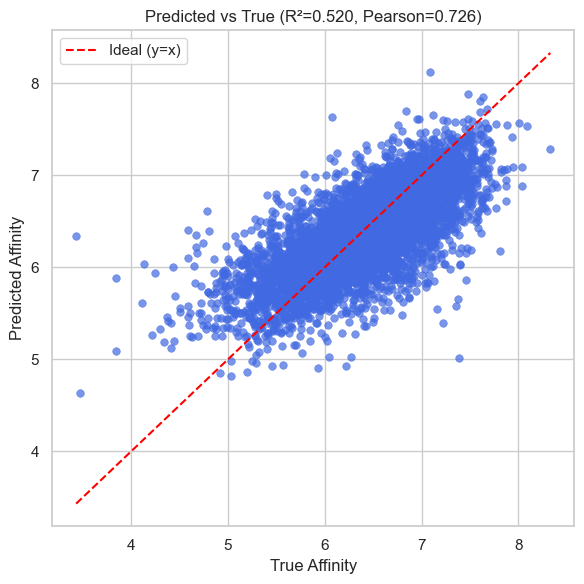

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 변환
y_true = test_true.view(-1).cpu().numpy()
y_pred = test_pred.view(-1).cpu().numpy()

plt.figure(figsize=(6,6))
sns.set(style="whitegrid")

# 산점도
sns.scatterplot(x=y_true, y=y_pred, s=30, alpha=0.7, color='royalblue', edgecolor=None)

# 기준선 (y=x)
plt.plot([y_true.min(), y_true.max()],
         [y_true.min(), y_true.max()],
         color='red', linestyle='--', linewidth=1.5, label='Ideal (y=x)')

plt.xlabel("True Affinity")
plt.ylabel("Predicted Affinity")
plt.title(f"Predicted vs True (R²={test_r2:.3f}, Pearson={test_pearson:.3f})")
plt.legend()
plt.tight_layout()
plt.show()


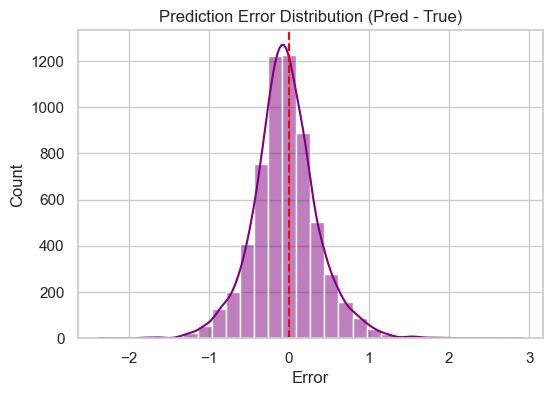

In [30]:
errors = y_pred - y_true
plt.figure(figsize=(6,4))
sns.histplot(errors, bins=30, kde=True, color='purple')
plt.axvline(0, color='red', linestyle='--')
plt.title("Prediction Error Distribution (Pred - True)")
plt.xlabel("Error")
plt.ylabel("Count")
plt.show()


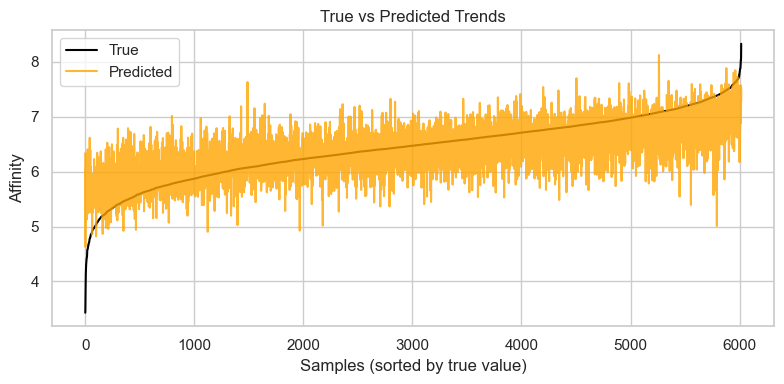

In [31]:
plt.figure(figsize=(8,4))
sorted_idx = np.argsort(y_true)
plt.plot(np.arange(len(y_true)), y_true[sorted_idx], label="True", color='black')
plt.plot(np.arange(len(y_pred)), y_pred[sorted_idx], label="Predicted", color='orange', alpha=0.8)
plt.legend()
plt.xlabel("Samples (sorted by true value)")
plt.ylabel("Affinity")
plt.title("True vs Predicted Trends")
plt.tight_layout()
plt.show()
